# **Data Visulization**

In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
# import libararies 



In [2]:
#import online data of titanic as seaborn libararies
df = sns.load_dataset('titanic')



<Axes: xlabel='age', ylabel='fare'>

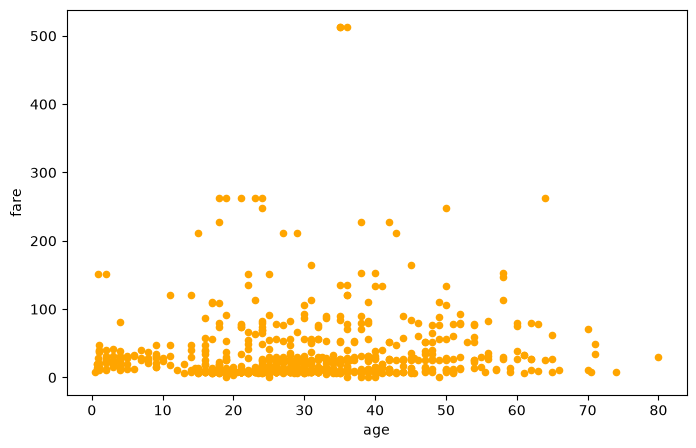

In [3]:
# make a plot to used a pandas 
df.plot(kind = 'scatter' , x='age',y='fare',color='orange',figsize=(8,5))

<Axes: xlabel='age', ylabel='fare'>

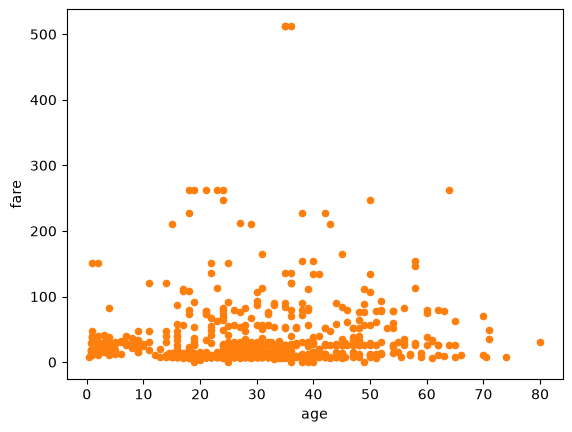

In [4]:
# make a plot using color hex code 
df.plot(kind='scatter',x='age',y='fare',color='#FE7F0E')

Text(0.5, 0, 'Gender')

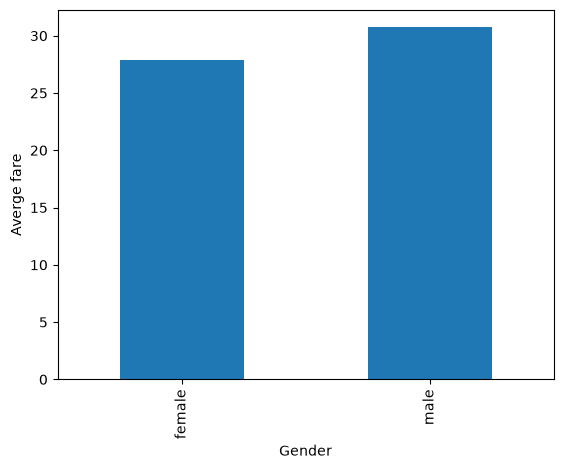

In [5]:
df.groupby('sex')['age'].mean().plot(kind='bar')# use pandas

plt.ylabel('Averge fare')#use matplot
plt.xlabel('Gender')#use matplot

In [6]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<Axes: xlabel='survived', ylabel='fare'>

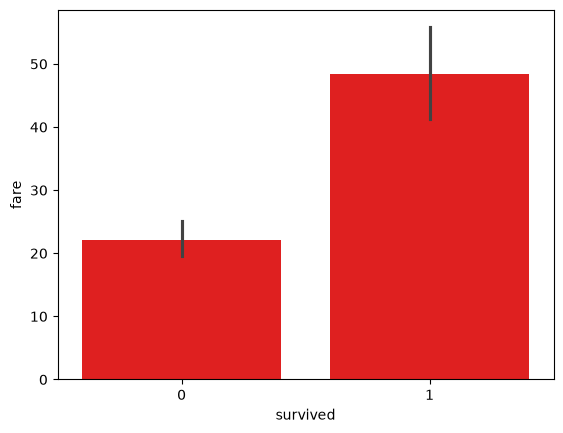

In [7]:
# make a plot use seaborn
sns.barplot(data=df,x='survived',y='fare',color='red')

<Axes: xlabel='sex', ylabel='fare'>

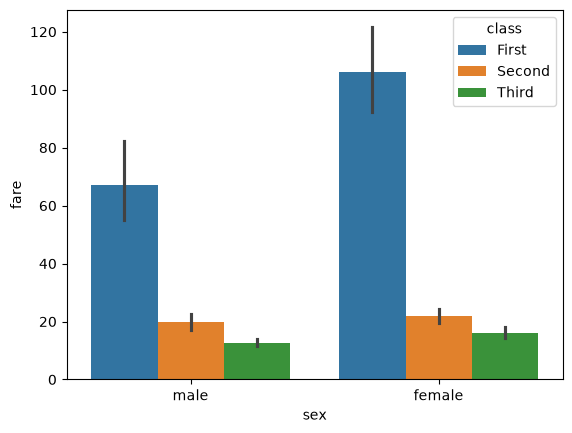

In [8]:
sns.barplot(data=df,x='sex',y='fare',hue='class') # yah pai grouping ke ha ham nan hue cammand use kr ka

<Axes: xlabel='age', ylabel='fare'>

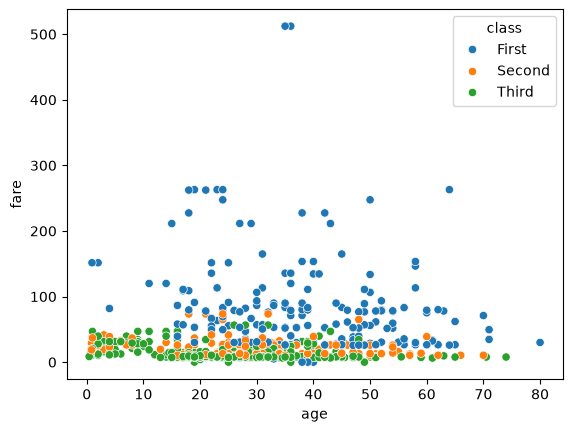

In [9]:
sns.scatterplot(data=df,x='age',y='fare',hue='class')

In [16]:
import plotly.express as px
fig = px.scatter(df,x='age',y='fare',color='sex')
fig.show()

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import pandas as pd

us_cities = pd.read_csv("https://raw.githubusercontent.com/plotly/datasets/master/us-cities-top-1k.csv")
us_cities = us_cities.query("State in ['New York', 'Ohio']")

import plotly.express as px

fig = px.line_map(us_cities, lat="lat", lon="lon", color="State", zoom=3, height=300)

fig.update_layout(map_style="open-street-map", map_zoom=4, map_center_lat = 41,
    margin={"r":0,"t":0,"l":0,"b":0})

fig.show()

In [18]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import pandas as pd

# read in volcano database data
df = pd.read_csv(
    "https://raw.githubusercontent.com/plotly/datasets/master/volcano_db.csv",
    encoding="iso-8859-1",
)

# frequency of Country
freq = df['Country'].value_counts().reset_index()
freq.columns = ['x', 'Country']

# read in 3d volcano surface data
df_v = pd.read_csv("https://raw.githubusercontent.com/plotly/datasets/master/volcano.csv")

# Initialize figure with subplots
fig = make_subplots(
    rows=2, cols=2,
    column_widths=[0.6, 0.4],
    row_heights=[0.4, 0.6],
    specs=[[{"type": "scattergeo", "rowspan": 2}, {"type": "bar"}],
           [            None                    , {"type": "surface"}]])

# Add scattergeo globe map of volcano locations
fig.add_trace(
    go.Scattergeo(lat=df["Latitude"],
                  lon=df["Longitude"],
                  mode="markers",
                  hoverinfo="text",
                  showlegend=False,
                  marker=dict(color="crimson", size=4, opacity=0.8)),
    row=1, col=1
)

# Add locations bar chart
fig.add_trace(
    go.Bar(x=freq["x"][0:10],y=freq["Country"][0:10], marker=dict(color="crimson"), showlegend=False),
    row=1, col=2
)

# Add 3d surface of volcano
fig.add_trace(
    go.Surface(z=df_v.values.tolist(), showscale=False),
    row=2, col=2
)

# Update geo subplot properties
fig.update_geos(
    projection_type="orthographic",
    landcolor="white",
    oceancolor="MidnightBlue",
    showocean=True,
    lakecolor="LightBlue"
)

# Rotate x-axis labels
fig.update_xaxes(tickangle=45)

# Set theme, margin, and annotation in layout
fig.update_layout(
    template="plotly_dark",
    margin=dict(r=10, t=25, b=40, l=60),
    annotations=[
        dict(
            text="Source: NOAA",
            showarrow=False,
            xref="paper",
            yref="paper",
            x=0,
            y=0)
    ]
)

fig.show()

In [23]:
import plotly.express as px
df = px.data.gapminder()
px.scatter(df, x="gdpPercap", y="lifeExp", animation_frame="year", animation_group="country",
           size="pop", color="continent", hover_name="country",
           log_x=True, size_max=55, range_x=[100,100000], range_y=[25,90])

# **3D Plot**

In [20]:
import plotly.graph_objects as go
import pandas as pd

# Read data from a csv
z_data = pd.read_csv('https://raw.githubusercontent.com/plotly/datasets/master/api_docs/mt_bruno_elevation.csv')

fig = go.Figure(data=go.Surface(z=z_data, showscale=False))
fig.update_layout(
    title=dict(text='Mt Bruno Elevation'),
    width=400, height=400,
    margin=dict(t=40, r=0, l=20, b=20)
)

name = 'default'
# Default parameters which are used when `layout.scene.camera` is not provided
camera = dict(
    up=dict(x=0, y=0, z=1),
    center=dict(x=0, y=0, z=0),
    eye=dict(x=1.25, y=1.25, z=1.25)
)

fig.update_layout(scene_camera=camera, title=name)
fig.show()